# CNN & Hybrid Model

Trains and compares three model tiers:
- **XGNet**: CNN on freeze-frame heatmaps only (3 x 68 x 52)
- **HybridXGNet**: CNN + tabular features (distance, angle, body_part, ...)
- **Baselines**: Logistic Regression + XGBoost for reference

## 1. Load Data

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score, brier_score_loss

from data import load_features, split_data
from models import (
    train_baseline, train_xgboost,
    train_cnn, train_hybrid_cnn,
    make_X_tabular
)

features_df = load_features()
train, val, test = split_data(features_df)

print(f"Train: {len(train)} shots | {train['is_goal'].mean():.1%} goals")
print(f"Val:   {len(val)} shots | {val['is_goal'].mean():.1%} goals")
print(f"Test:  {len(test)} shots | {test['is_goal'].mean():.1%} goals")
print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Loading existing features from cache...
Train: 8396 | Val: 1807 | Test: 1841
Train: 8396 shots | 10.4% goals
Val:   1807 shots | 9.1% goals
Test:  1841 shots | 9.6% goals

Device: cuda


## 2. Verify Heatmap Input Shape

In [2]:
# Confirm input shape matches CNN architecture: (3, 68, 52)
sample = np.stack(train['heatmap'].values)
print(f"Heatmap batch shape: {sample.shape}")
print(f"Expected:            (n, 3, 68, 52)")
assert sample.shape[1:] == (3, 68, 52), "❌ Unexpected heatmap shape!"
print("✅ Shape confirmed")

Heatmap batch shape: (8396, 3, 68, 52)
Expected:            (n, 3, 68, 52)
✅ Shape confirmed


## 3. Train XGNet (Heatmap only)

In [3]:
print("Training XGNet (heatmap only)...")
model_cnn, train_losses_cnn, val_losses_cnn = train_cnn(train, val, epochs=50, batch_size=64, lr=0.005, weight_decay=1e-3)

Training XGNet (heatmap only)...
Epoch   5 | Train Loss: 0.6141 | Val Loss: 0.6032
Epoch  10 | Train Loss: 0.5982 | Val Loss: 0.5756
Epoch  15 | Train Loss: 0.5711 | Val Loss: 0.5797
Epoch  20 | Train Loss: 0.5587 | Val Loss: 0.5625
--> Early Stopping in Epoche 24. Best Val Loss: 0.5532


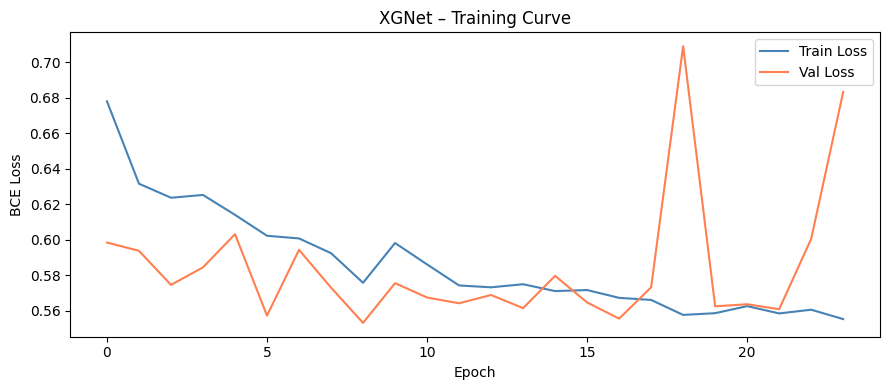

In [4]:
# Training curve — check for overfitting
# Ideal: both curves decrease and converge
# Red flag: val loss increases while train keeps dropping
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses_cnn, label='Train Loss', color='steelblue')
ax.plot(val_losses_cnn,   label='Val Loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('XGNet – Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Evaluate XGNet on val set
# BCEWithLogitsLoss has no Sigmoid → apply manually at inference
X_val_heatmap = torch.tensor(np.stack(val['heatmap'].values), dtype=torch.float32)
y_val = val['is_goal'].values

model_cnn.eval()
with torch.no_grad():
    y_proba_cnn = torch.sigmoid(model_cnn(X_val_heatmap)).numpy()

auc_cnn   = roc_auc_score(y_val, y_proba_cnn)
brier_cnn = brier_score_loss(y_val, y_proba_cnn)
print(f"XGNet (heatmap only) →  AUC: {auc_cnn:.3f}  |  Brier: {brier_cnn:.4f}")

XGNet (heatmap only) →  AUC: 0.766  |  Brier: 0.1083


## 4. Train HybridXGNet (CNN + Tabular)

In [6]:
print("Training HybridXGNet (CNN + tabular)...")
model_hybrid, train_losses_hybrid, val_losses_hybrid, preprocessor = train_hybrid_cnn(train, val, epochs=50, batch_size=64, lr=0.005, weight_decay=1e-3)

Training HybridXGNet (CNN + tabular)...
Epoch   5 | Train Loss: 0.6088 | Val Loss: 0.5556
Epoch  10 | Train Loss: 0.5817 | Val Loss: 0.5454
Epoch  15 | Train Loss: 0.5652 | Val Loss: 0.5505
Epoch  20 | Train Loss: 0.5553 | Val Loss: 0.5390
Epoch  25 | Train Loss: 0.5572 | Val Loss: 0.5355
Epoch  30 | Train Loss: 0.5598 | Val Loss: 0.5403
Epoch  35 | Train Loss: 0.5531 | Val Loss: 0.5432
--> Early Stopping in Epoche 37. Best Val Loss: 0.5259


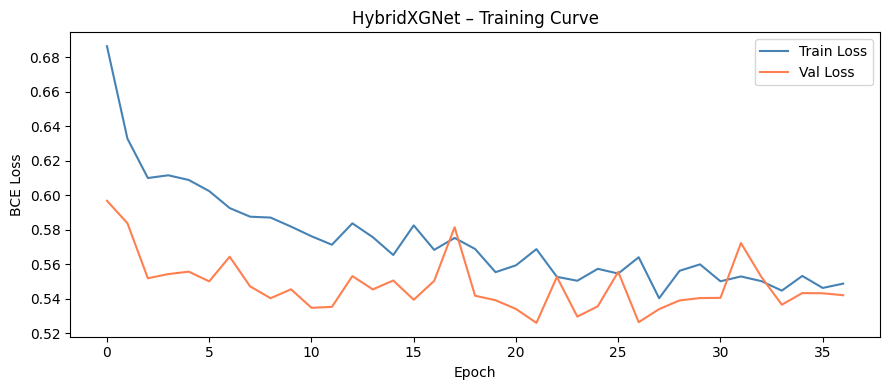

In [7]:
# Training curve for Hybrid model
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses_hybrid, label='Train Loss', color='steelblue')
ax.plot(val_losses_hybrid,   label='Val Loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('HybridXGNet – Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
X_val_tab = preprocessor.fit_transform(make_X_tabular(train))  # fit on train
X_val_tab = preprocessor.transform(make_X_tabular(val))        # transform val

if hasattr(X_val_tab, 'toarray'):
    X_val_tab = X_val_tab.toarray()

X_val_tab_t = torch.tensor(X_val_tab, dtype=torch.float32)

model_hybrid.eval()
with torch.no_grad():
    y_proba_hybrid = torch.sigmoid(model_hybrid(X_val_heatmap, X_val_tab_t)).numpy()

auc_hybrid   = roc_auc_score(y_val, y_proba_hybrid)
brier_hybrid = brier_score_loss(y_val, y_proba_hybrid)
print(f"HybridXGNet (CNN + tabular) →  AUC: {auc_hybrid:.3f}  |  Brier: {brier_hybrid:.4f}")

HybridXGNet (CNN + tabular) →  AUC: 0.787  |  Brier: 0.0865


## 5. Full Model Comparison

In [9]:
# Train baselines for comparison
model_lr  = train_baseline(train)
model_xgb = train_xgboost(train)

X_val_lr  = val[['distance', 'angle']].values
X_val_xgb = make_X_tabular(val)

auc_lr    = roc_auc_score(y_val, model_lr.predict_proba(X_val_lr)[:, 1])
brier_lr  = brier_score_loss(y_val, model_lr.predict_proba(X_val_lr)[:, 1])

auc_xgb   = roc_auc_score(y_val, model_xgb.predict_proba(X_val_xgb)[:, 1])
brier_xgb = brier_score_loss(y_val, model_xgb.predict_proba(X_val_xgb)[:, 1])

# StatsBomb reference
sb_xg  = val['statsbomb_xg'].values
mask   = ~np.isnan(sb_xg)
auc_sb = roc_auc_score(y_val[mask], sb_xg[mask])
brier_sb = brier_score_loss(y_val[mask], sb_xg[mask])

# Summary table
results = [
    ('Logistic Regression',       auc_lr,     brier_lr),
    ('XGBoost',                   auc_xgb,    brier_xgb),
    ('XGNet (heatmap only)',       auc_cnn,    brier_cnn),
    ('HybridXGNet (CNN + tabular)',auc_hybrid, brier_hybrid),
    ('StatsBomb xG (reference)',   auc_sb,     brier_sb),
]

print(f"{'Model':<30} {'AUC':>6}  {'Brier':>7}")
print("-" * 48)
for i, (name, auc, brier) in enumerate(results):
    if i == len(results) - 1:
        print("-" * 48)
    print(f"{name:<30} {auc:>6.3f}  {brier:>7.4f}")

Model                             AUC    Brier
------------------------------------------------
Logistic Regression             0.712   0.0783
XGBoost                         0.758   0.0762
XGNet (heatmap only)            0.766   0.1083
HybridXGNet (CNN + tabular)     0.787   0.0865
------------------------------------------------
StatsBomb xG (reference)        0.792   0.0739


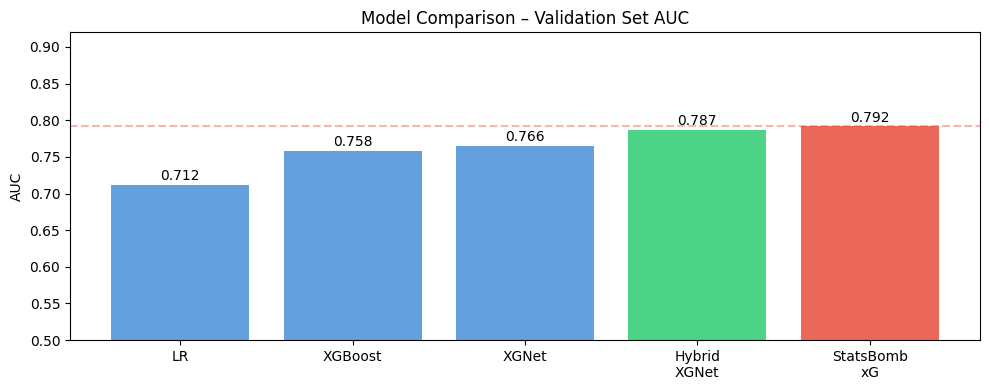

In [10]:
# Visual AUC comparison
names  = ['LR', 'XGBoost', 'XGNet', 'Hybrid\nXGNet', 'StatsBomb\nxG']
aucs   = [r[1] for r in results]
colors = ['#4a90d9', '#4a90d9', '#4a90d9', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(names, aucs, color=colors, alpha=0.85)
ax.set_ylim(0.5, 0.92)
ax.set_ylabel('AUC')
ax.set_title('Model Comparison – Validation Set AUC')
ax.axhline(auc_sb, color='#e74c3c', linestyle='--', alpha=0.4)

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Training Curve Comparison

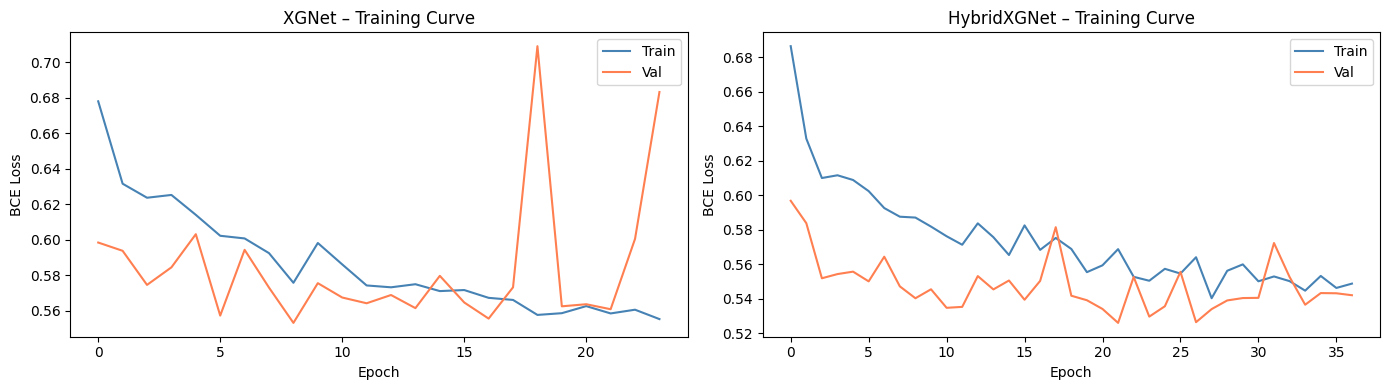

In [11]:
# Side-by-side training curves for XGNet vs HybridXGNet
# Useful to spot if one overfits more than the other
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, train_l, val_l, title in [
    (axes[0], train_losses_cnn,    val_losses_cnn,    'XGNet'),
    (axes[1], train_losses_hybrid, val_losses_hybrid, 'HybridXGNet'),
]:
    ax.plot(train_l, label='Train', color='steelblue')
    ax.plot(val_l,   label='Val',   color='coral')
    ax.set_title(f'{title} – Training Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. xG Distribution – HybridXGNet vs. Ground Truth

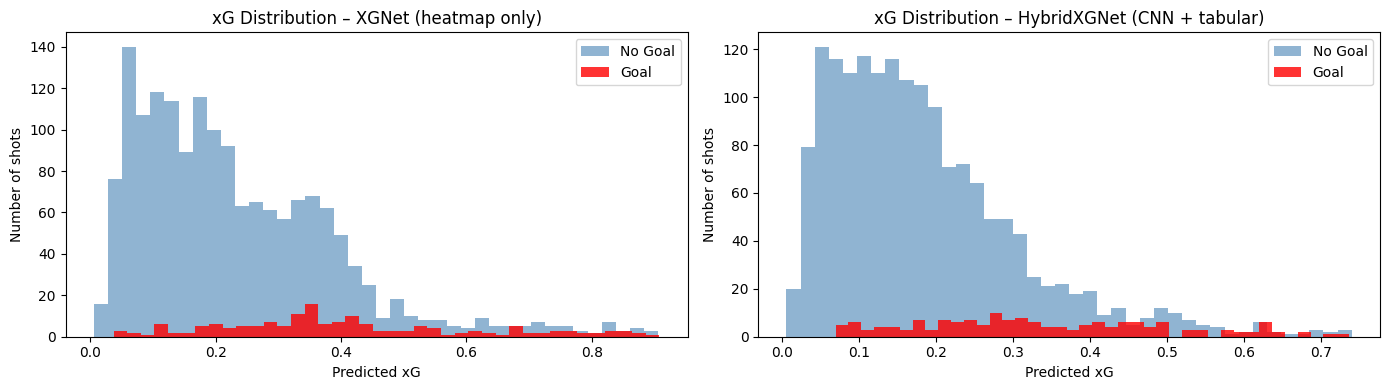

In [12]:
# Goals should cluster toward higher predicted xG values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y_proba, title in [
    (axes[0], y_proba_cnn,    'XGNet (heatmap only)'),
    (axes[1], y_proba_hybrid, 'HybridXGNet (CNN + tabular)'),
]:
    ax.hist(y_proba[y_val == 0], bins=40, alpha=0.6, label='No Goal', color='steelblue')
    ax.hist(y_proba[y_val == 1], bins=40, alpha=0.8, label='Goal',    color='red')
    ax.set_xlabel('Predicted xG')
    ax.set_ylabel('Number of shots')
    ax.set_title(f'xG Distribution – {title}')
    ax.legend()

plt.tight_layout()
plt.show()